# 4bis — Molecular Similarity Analysis

Detailed analysis of chemical-structure similarity across the CSD, based on Morgan fingerprints (radius=2, 2048 bits) computed over all unique SMILES in `csd_cleaned.csv`.

Source data: `similarity_enriched.csv` (built in `4_Explore_Data.ipynb`).

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from rdkit import Chem
from rdkit.Chem import rdFingerprintGenerator
from rdkit import DataStructs


In [18]:
data = pd.read_csv("csd_cleaned.csv")
sim_top10 = pd.read_csv("similarity_enriched.csv")
sim_top10

,smiles_1,nb_forms_1,identifiers_1,smiles_2,nb_forms_2,identifiers_2,tanimoto
0,CC(=O)NN1C=NN=C1N(N=Cc1c(Cl)cccc1Cl)C(C)=O,1,AABHTZ,Nn1cnnc1NN=Cc1c(Cl)cccc1Cl,1,CIJGAD,0.379310
1,CC(=O)NN1C=NN=C1N(N=Cc1c(Cl)cccc1Cl)C(C)=O,1,AABHTZ,CN(N=Cc1c(Cl)cccc1Cl)C(=O)C1COC(=O)N1C,1,HUMJOQ,0.348485
2,CC(=O)NN1C=NN=C1N(N=Cc1c(Cl)cccc1Cl)C(C)=O,1,AABHTZ,CC(=O)NC1=NN(C(=O)C1=Cc1c(Cl)cccc1Cl)c1ccccc1,1,BAKYAP,0.338462
3,CC(=O)NN1C=NN=C1N(N=Cc1c(Cl)cccc1Cl)C(C)=O,1,AABHTZ,CN1C=NC(=C1N)C1=NN=CN1NC(C)=O,1,TUQBAI,0.327869
4,CC(=O)NN1C=NN=C1N(N=Cc1c(Cl)cccc1Cl)C(C)=O,1,AABHTZ,Clc1cccc(Cl)c1C=NNC(=O)c1cnccn1,1,HUGDAP,0.322581
...,...,...,...,...,...,...,...
3040315,Clc1ccc(cc1)C1=Nc2ccccc2S1,1,ZUYBOM01,Clc1ccc2SC(=Nc2c1)c1ccccc1,1,QEDQIB,0.647059
3040316,Clc1ccc(cc1)C1=Nc2ccccc2S1,1,ZUYBOM01,S1c2ccccc2N=C1C1=Nc2ccccc2S1,3,FOCZON|FOCZON01|FOCZON02,0.642857
3040317,Clc1ccc(cc1)C1=Nc2ccccc2S1,1,ZUYBOM01,S1c2ccccc2N=C1c1ccc(cc1)N(c1ccccc1)c1ccccc1,2,ZOLREA|ZOLREA01,0.628571
3040318,Clc1ccc(cc1)C1=Nc2ccccc2S1,1,ZUYBOM01,FC(F)(F)c1ccc(cc1)C1=Nc2ccccc2S1,1,PABWAV,0.628571


#### Same molecule, different SMILES string

Fingerprints are deduplicated by SMILES (see rationale above), but the same molecule (same InChI) can be recorded under more than one SMILES string in the CSD — those duplicates wouldn't get merged and would show up as separate entries, each with its own top-10 neighbors.

In [19]:
smiles_per_inchi = data.groupby("inchi")["smiles"].nunique()
split_inchi = smiles_per_inchi[smiles_per_inchi > 1]

print(f"Distinct InChI                  : {len(smiles_per_inchi)}")
print(f"  with >1 SMILES string recorded : {len(split_inchi)} ({100 * len(split_inchi) / len(smiles_per_inchi):.1f}%)")

Distinct InChI                  : 311511
  with >1 SMILES string recorded : 305 (0.1%)


In [20]:
data[data["inchi"].isin(split_inchi.index)][["inchi", "smiles"]].drop_duplicates().sort_values("inchi").head(20)

,inchi,smiles
272433,InChI=1S/C100Cl22/c101-79-27-7-3-5-2-1-6-4-10-...,ClC12C3=C4C5=C6C7=C3C3=C8C9=C%10C%11=C%12C8=C8...
272434,InChI=1S/C100Cl22/c101-79-27-7-3-5-2-1-6-4-10-...,ClC12C3=C4C5=C6C7=C3C3=C8C9=C%10C%11=C3C3(Cl)C...
263079,InChI=1S/C102Cl20/c103-83-51-26-6-5-2-11-14-7(...,ClC12C3=C4C5=C6C7=C8C9=C%10C%11=C%12C(=C59)C3=...
263080,InChI=1S/C102Cl20/c103-83-51-26-6-5-2-11-14-7(...,ClC12C3=C4C5=C6C7=C8C9=C5C5=C3C3=C1C1=C%10C%11...
241364,InChI=1S/C104Cl24/c105-81-21-1-2-6-10-14-18-20...,ClC12C3=C4C5=C6C7=C8C9=C5C5(Cl)C%10=C4C4=C%11C...
241363,InChI=1S/C104Cl24/c105-81-21-1-2-6-10-14-18-20...,ClC12C3=C4C5=C6C7=C8C9=C%10C%11=C%12C8(Cl)C8=C...
136002,InChI=1S/C10H10N2/c1-7-8(2)12-10-6-4-3-5-9(10)...,Cc1nc2ccccc2nc1C
136001,InChI=1S/C10H10N2/c1-7-8(2)12-10-6-4-3-5-9(10)...,CC1=Nc2ccccc2N=C1C
318386,InChI=1S/C10H10N2O2/c13-10(14)6-5-9-11-7-3-1-2...,O=C([O-])CCC1=[NH+]c2ccccc2N1
253154,InChI=1S/C10H10N2O2/c13-10(14)6-5-9-11-7-3-1-2...,OC(=O)CCC1=Nc2ccccc2N1


By construction (dedup on unique SMILES, self-matches excluded — see `molecule_similarity.py`), `smiles_1` and `smiles_2` should never be equal. Confirming there's no leak before trusting the rest of this analysis.

In [21]:
exact_match = sim_top10[sim_top10["tanimoto"] == 1].copy()
same_smiles = (exact_match["smiles_1"] == exact_match["smiles_2"]).sum()

print(f"Pairs with tanimoto == 1        : {len(exact_match)}")
print(f"  of which smiles_1 == smiles_2 : {same_smiles}")

Pairs with tanimoto == 1        : 9736
  of which smiles_1 == smiles_2 : 0


In [22]:
smiles_to_inchi = data.drop_duplicates("smiles").set_index("smiles")["inchi"]
exact_match["inchi_1"] = exact_match["smiles_1"].map(smiles_to_inchi)
exact_match["inchi_2"] = exact_match["smiles_2"].map(smiles_to_inchi)
same_inchi = (exact_match["inchi_1"] == exact_match["inchi_2"]).sum()

print(f"  same InChI (duplicate SMILES, same molecule) : {same_inchi} ({100 * same_inchi / len(exact_match):.1f}%)")
print(f"  different InChI (fingerprint collision)      : {len(exact_match) - same_inchi} ({100 * (1 - same_inchi / len(exact_match)):.1f}%)")

exact_match

  same InChI (duplicate SMILES, same molecule) : 224 (2.3%)
  different InChI (fingerprint collision)      : 9512 (97.7%)


,smiles_1,nb_forms_1,identifiers_1,smiles_2,nb_forms_2,identifiers_2,tanimoto,inchi_1,inchi_2
1260,CC(=O)NCCCCCNC(C)=O,1,ABAWUW,CC(=O)NCCCCCCNC(C)=O,1,DAMEDA,1.0,InChI=1S/C9H18N2O2/c1-8(12)10-6-4-3-5-7-11-9(2...,InChI=1S/C10H20N2O2/c1-9(13)11-7-5-3-4-6-8-12-...
1840,O=P(c1ccccc1)(c1ccccc1)c1cccc2OCCOCCOCCOCCOc3c...,1,ABEHEW,O=P(c1ccccc1)(c1ccccc1)c1cccc2OCCOCCOCCOc3cccc...,1,ABEHOG,1.0,"InChI=1S/C44H42O7P2/c45-52(35-15-5-1-6-16-35,3...","InChI=1S/C42H38O6P2/c43-49(33-15-5-1-6-16-33,3..."
1841,O=P(c1ccccc1)(c1ccccc1)c1cccc2OCCOCCOCCOCCOc3c...,1,ABEHEW,O=P(c1ccccc1)(c1ccccc1)c1cccc2OCCOCCOCCOCCOCCO...,1,ABEHIA,1.0,"InChI=1S/C44H42O7P2/c45-52(35-15-5-1-6-16-35,3...","InChI=1S/C46H46O8P2/c47-55(37-15-5-1-6-16-37,3..."
1850,O=P(c1ccccc1)(c1ccccc1)c1cccc2OCCOCCOCCOCCOCCO...,1,ABEHIA,O=P(c1ccccc1)(c1ccccc1)c1cccc2OCCOCCOCCOc3cccc...,1,ABEHOG,1.0,"InChI=1S/C46H46O8P2/c47-55(37-15-5-1-6-16-37,3...","InChI=1S/C42H38O6P2/c43-49(33-15-5-1-6-16-33,3..."
1851,O=P(c1ccccc1)(c1ccccc1)c1cccc2OCCOCCOCCOCCOCCO...,1,ABEHIA,O=P(c1ccccc1)(c1ccccc1)c1cccc2OCCOCCOCCOCCOc3c...,1,ABEHEW,1.0,"InChI=1S/C46H46O8P2/c47-55(37-15-5-1-6-16-37,3...","InChI=1S/C44H42O7P2/c45-52(35-15-5-1-6-16-35,3..."
...,...,...,...,...,...,...,...,...,...
3038320,CCCCCCN(C)c1c2C3c4ccccc4C(c4ccccc34)c2c(C#Cc2c...,2,UVIZIM|UVIZIM01,CCCCCCCCN(C)c1c2C3c4ccccc4C(c4ccccc34)c2c(C#Cc...,4,PIYCIN|PIYCIN02|PIYCIN03|PIYCIN07,1.0,InChI=1S/C57H45N/c1-3-4-5-16-32-58(2)57-55-51-...,InChI=1S/C59H49N/c1-3-4-5-6-7-18-34-60(2)59-57...
3039960,Clc1ccc(cc1)C1=CN(c2ccccc2)C(=C1C(=O)c1ccccc1)...,1,ZABXAG,Clc1ccc(cc1)C1=C(C(=O)c2ccccc2)C(=CN1c1ccccc1)...,1,ZACFET,1.0,InChI=1S/C29H20ClNO/c30-24-18-16-21(17-19-24)2...,InChI=1S/C29H20ClNO/c30-24-18-16-22(17-19-24)2...
3040020,Clc1ccc(cc1)C1=C(C(=O)c2ccccc2)C(=CN1c1ccccc1)...,1,ZACFET,Clc1ccc(cc1)C1=CN(c2ccccc2)C(=C1C(=O)c1ccccc1)...,1,ZABXAG,1.0,InChI=1S/C29H20ClNO/c30-24-18-16-22(17-19-24)2...,InChI=1S/C29H20ClNO/c30-24-18-16-21(17-19-24)2...
3040150,COC(=O)c1ccc(cc1)C#Cc1cc2CCc3ccc(CCc1cc2)cc3C#...,1,ZAFVAI,COC(=O)c1ccc(cc1)C#Cc1cc2CCc3ccc(CCc1cc2)c(c3)...,1,ZAFVIQ,1.0,InChI=1S/C36H28O4/c1-39-35(37)31-17-3-25(4-18-...,InChI=1S/C36H28O4/c1-39-35(37)31-15-5-25(6-16-...


#### Polymorphism vs. chemical neighborhood

Check whether each polymorphic molecule has at least one polymorphic molecule among its 10 nearest chemical neighbors (`similarity_enriched.csv`), and flag the ones that don't.

In [23]:
nb_forms_1 = (
    sim_top10.drop_duplicates("smiles_1")
    .set_index("smiles_1")["nb_forms_1"]
)
base_rate = (nb_forms_1 > 1).mean()

print(f"Unique molecules : {len(nb_forms_1)}")
print(f"Polymorphic      : {(nb_forms_1 > 1).sum()} ({100 * base_rate:.1f}%)")

Unique molecules : 304032
Polymorphic      : 15448 (5.1%)


In [24]:
sim_top10["neighbor_polymorphic"] = sim_top10["nb_forms_2"] > 1

poly_sim = sim_top10[sim_top10["nb_forms_1"] > 1]
n_poly = poly_sim["smiles_1"].nunique()

n_poly_neighbors = poly_sim.groupby("smiles_1")["neighbor_polymorphic"].sum()
best_any_sim = poly_sim.groupby("smiles_1")["tanimoto"].max()
isolated = n_poly_neighbors[n_poly_neighbors == 0]

expected_zero_if_random = (1 - base_rate) ** 10

print(f"Polymorphic molecules                    : {n_poly}")
print(f"  zero polymorphic neighbor in top10     : {len(isolated)} ({100 * len(isolated) / n_poly:.1f}%)")
print(f"  expected if neighbors were random      : {100 * expected_zero_if_random:.1f}%")
print(f"  best-neighbor similarity, all polymorphs : {best_any_sim.mean():.3f}")
print(f"  best-neighbor similarity, isolated only  : {best_any_sim.loc[isolated.index].mean():.3f}")

Polymorphic molecules                    : 15448
  zero polymorphic neighbor in top10     : 3249 (21.0%)
  expected if neighbors were random      : 59.4%
  best-neighbor similarity, all polymorphs : 0.691
  best-neighbor similarity, isolated only  : 0.655


In [25]:
identifiers_1 = (
    sim_top10.drop_duplicates("smiles_1")
    .set_index("smiles_1")["identifiers_1"]
    .str.split("|")
)

isolated_detail = pd.DataFrame({
    "num_forms": nb_forms_1.loc[isolated.index],
    "best_neighbor_sim": best_any_sim.loc[isolated.index],
    "identifiers": identifiers_1.loc[isolated.index],
}).sort_values("num_forms", ascending=False)

isolated_detail.head(20)

,num_forms,best_neighbor_sim,identifiers
smiles_1,,,
NC(=O)C1=NN(C=N1)C1OC(CO)C(O)C1O,30,0.687500,"[VIRAZL, VIRAZL01, VIRAZL02, VIRAZL03, VIRAZL0..."
CC1=C(C)C(=O)N(N=C1O)c1ccccc1,27,0.485714,"[COXZAS01, COXZAS02, COXZAS03, COXZAS04, COXZA..."
O=C1OC(=O)c2cc3C(=O)OC(=O)c3cc12,23,0.750000,"[PYMDAN, PYMDAN01, PYMDAN02, PYMDAN03, PYMDAN0..."
OC(=O)c1ccc(cc1)c1cc(cc(c1)C1=CC=C(c2cc(cc(c2)c2ccc(cc2)C(O)=O)c2ccc(cc2)C(O)=O)C2=NSN=C12)c1ccc(cc1)C(O)=O,18,0.675676,"[ACOWIC, OLOYAT, OLOYEX, OLOYIB, OLOYOH, OLOYU..."
Nc1nc(N)nc(N)n1,17,0.727273,"[MELAMI, MELAMI01, MELAMI02, MELAMI03, MELAMI0..."
CC(C)Cc1ccc(cc1)C(C)C(O)=O,15,0.625000,"[COTYOA, COTYOA01, IBPRAC, IBPRAC01, IBPRAC03,..."
COc1ccc(cc1N(=O)=O)N(=O)=O,14,0.724138,"[FESNEW02, FESNEW11, FESNEW12, FESNEW13, FESNE..."
CC(=[NH+]C1CCCc2ccccc12)c1cc(ccc1[O-])N(=O)=O,14,0.393443,"[CACTOU, CACTOU01, CACTOU02, CACTOU03, CACTOU0..."
N1C=CN=C1c1ccccc1,12,0.640000,"[OBUQUZ, OBUQUZ01, OBUQUZ02, OBUQUZ03, OBUQUZ0..."


Zoom on the most isolated polymorphic molecule (highest `num_forms`, 0 polymorphic neighbors) — its full top-10 neighborhood, to see why none of them are flagged as polymorphic.

In [26]:
first_smiles = isolated_detail.index[0]
print(f"Molecule    : {first_smiles}")
print(f"Identifiers : {identifiers_1.loc[first_smiles]}")
print()

neighbors = (
    sim_top10[sim_top10["smiles_1"] == first_smiles]
    .sort_values("tanimoto", ascending=False)
)
neighbors[["smiles_2", "identifiers_2", "tanimoto", "nb_forms_2", "neighbor_polymorphic"]]

Molecule    : NC(=O)C1=NN(C=N1)C1OC(CO)C(O)C1O
Identifiers : ['VIRAZL', 'VIRAZL01', 'VIRAZL02', 'VIRAZL03', 'VIRAZL04', 'VIRAZL05', 'VIRAZL06', 'VIRAZL07', 'VIRAZL08', 'VIRAZL09', 'VIRAZL10', 'VIRAZL11', 'VIRAZL12', 'VIRAZL13', 'VIRAZL14', 'VIRAZL15', 'VIRAZL16', 'VIRAZL17', 'VIRAZL18', 'VIRAZL19', 'VIRAZL20', 'VIRAZL21', 'VIRAZL22', 'VIRAZL23', 'VIRAZL24', 'VIRAZL25', 'VIRAZL28', 'VIRAZL29', 'VIRAZL30', 'VIRAZL31']



,smiles_2,identifiers_2,tanimoto,nb_forms_2,neighbor_polymorphic
2501590,NC(=O)C1=NN(C=N1)C1OC(COS(N)(=O)=O)C(O)C1O,JAZVEL10,0.687500,1,False
2501591,NS(=O)(=O)C1=NN(C=N1)C1OC(CO)C(O)C1O,VAWMOV,0.666667,1,False
2501592,NC(=O)C1=C(N)N(C=N1)C1OC(CO)C(O)C1O,ARBIMC10,0.562500,1,False
2501593,NC(=S)C1=NN(C=N1)C1OC(COS(N)(=O)=O)C(O)C1O,JAZVIP10,0.547170,1,False
2501594,NC(=O)C1=NC=CN(C2OC(CO)C(O)C2O)C1=O,DAQCUW,0.540000,1,False
2501595,NC(=O)C1=NC(=NN1C1OC(CO)C(O)C1O)Br,AXEJUI,0.500000,1,False
2501596,OCC1OC(C(O)C1O)N1C=CC(=O)N=C1,OSOTEW,0.469388,1,False
2501597,NC(=O)C1=NC(=CN(C2OC(CO)C(O)C2O)C1=O)F,DAQCOQ,0.462963,1,False
2501598,NC(=O)C1=CN(C=CC1=O)C1OC(CO)C(O)C1O,RFPNCX10,0.461538,1,False
2501599,NS(=O)(=O)OCC1OC(C(O)C1O)N1C=NC(=N1)C#N,JAZVOV10,0.454545,1,False


No polymorphic molecule has *all* 10 neighbors polymorphic — the closest is 9/10. Distribution below, then the molecules closest to that extreme (the opposite of the isolated ones above).

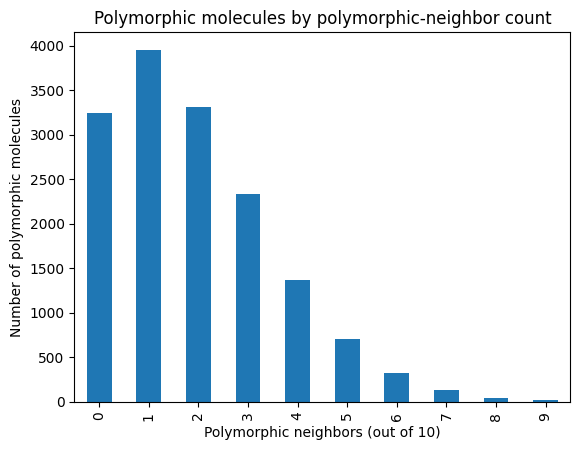

In [27]:
n_poly_neighbors.value_counts().sort_index().plot(kind="bar")
plt.xlabel("Polymorphic neighbors (out of 10)")
plt.ylabel("Number of polymorphic molecules")
plt.title("Polymorphic molecules by polymorphic-neighbor count")
plt.show()

In [28]:
most_embedded = n_poly_neighbors[n_poly_neighbors >= 9]
embedded_detail = pd.DataFrame({
    "num_forms": nb_forms_1.loc[most_embedded.index],
    "n_polymorphic_neighbors": most_embedded,
    "best_neighbor_sim": best_any_sim.loc[most_embedded.index],
    "identifiers": identifiers_1.loc[most_embedded.index],
}).sort_values("n_polymorphic_neighbors", ascending=False)

embedded_detail

,num_forms,n_polymorphic_neighbors,best_neighbor_sim,identifiers
smiles_1,,,,
CC(C)(C)c1ccc(cc1)N=Cc1ccccc1O,2,9,0.733333,"[FAXXUZ, FAXXUZ01]"
N1C=NC=N1,5,9,0.266667,"[TRAZOL, TRAZOL01, TRAZOL02, TRAZOL03, TRAZOL04]"
NC(=O)c1ccc(N)cc1,3,9,0.764706,"[AMBZAM10, AMBZAM11, AMBZAM12]"
NC(=O)c1ccccc1,20,9,0.705882,"[BISYIP, BISYOV, BISYUB, BISZAI, BISZEM, BZAMI..."
OC(=O)C=Cc1ccc(O)cc1,3,9,0.680000,"[COUMAC, COUMAC01, COUMAC03, UHASEE]"
OC(=O)CCCC(O)=O,14,9,0.833333,"[GLURAC, GLURAC02, GLURAC03, GLURAC04, GLURAC0..."
OC(=O)CCCCCCCCC(O)=O,11,9,1.000000,"[SEBAAC, SEBAAC01, SEBAAC03, SEBAAC04, SEBAAC0..."
OC(=O)CCCCCCCCCC(O)=O,3,9,1.000000,"[UNDEAC10, UNDEAC11, UNDEAC12]"
OC(=O)c1c[nH+]cc(c1)C(=O)[O-],3,9,0.548387,[DINICA11]


Zoom on the 7th molecule above — its best neighbor has `tanimoto == 1`, worth checking whether that neighbor is a genuinely distinct structure or a near-duplicate SMILES of the same molecule.

In [29]:
target_smiles = embedded_detail.index[6]
print(f"Molecule    : {target_smiles}")
print(f"Identifiers : {identifiers_1.loc[target_smiles]}")
print()

neighbors = (
    sim_top10[sim_top10["smiles_1"] == target_smiles]
    .sort_values("tanimoto", ascending=False)
)
neighbors[["smiles_2", "identifiers_2", "tanimoto", "nb_forms_2", "neighbor_polymorphic"]]

Molecule    : OC(=O)CCCCCCCCC(O)=O
Identifiers : ['SEBAAC', 'SEBAAC01', 'SEBAAC03', 'SEBAAC04', 'SEBAAC05', 'SEBAAC06', 'SEBAAC07', 'SEBAAC08', 'SEBAAC09', 'SEBAAC10', 'SEBAAC11']



,smiles_2,identifiers_2,tanimoto,nb_forms_2,neighbor_polymorphic
2122030,OC(=O)CCCCCCCC(O)=O,AZELAC01|AZELAC03|AZELAC04|AZELAC05|AZELAC10|A...,1.000000,12,True
2122031,OC(=O)CCCCCC(O)=O,PIMELA|PIMELA01|PIMELA02|PIMELA03|PIMELA04|PIM...,1.000000,22,True
2122032,OC(=O)CCCCCCCCCCC(O)=O,DECDAC02|DECDAC10,1.000000,2,True
2122033,OC(=O)CCCCCCC(O)=O,SUBRAC|SUBRAC01|SUBRAC02|SUBRAC03|SUBRAC04|SUB...,1.000000,13,True
2122034,OC(=O)CCCCCCCCCCCC(O)=O,BRASAC10|BRASAC11|BRASAC12,1.000000,3,True
2122035,OC(=O)CCCCCCCCCCCCCC(O)=O,MUFTEP,1.000000,1,False
2122036,OC(=O)CCCCCCCCCC(O)=O,UNDEAC10|UNDEAC11|UNDEAC12,1.000000,3,True
2122037,OC(=O)CCCCC(O)=O,ADIPAC|ADIPAC02|ADIPAC03|ADIPAC04|ADIPAC06|ADI...,0.916667,24,True
2122038,OC(=O)CCCC(O)=O,GLURAC|GLURAC02|GLURAC03|GLURAC04|GLURAC06|GLU...,0.769231,14,True
2122039,CCCCCCCCCC(O)=O,ISEPEB|ISEPEB01,0.705882,2,True


#### Monomorphic molecules with a polymorphic look-alike

Symmetric question: among molecules currently recorded as monomorphic, which ones have a *very* similar neighbor that is polymorphic? These are candidates that might actually be polymorphic but understudied or not yet observed in the CSD.

In [30]:
mono_sim = sim_top10[sim_top10["nb_forms_1"] == 1]

poly_hits = mono_sim[mono_sim["neighbor_polymorphic"]].sort_values("tanimoto", ascending=False)
best_poly_neighbor = poly_hits.groupby("smiles_1").first()

n_mono = (nb_forms_1 == 1).sum()
print(f"Monomorphic molecules                   : {n_mono}")
print(f"  with >=1 polymorphic neighbor in top10 : {len(best_poly_neighbor)} ({100 * len(best_poly_neighbor) / n_mono:.1f}%)")

Monomorphic molecules                   : 288584
  with >=1 polymorphic neighbor in top10 : 149640 (51.9%)


In [31]:
candidates = best_poly_neighbor[best_poly_neighbor["tanimoto"] >= 0.9].copy()
candidates["identifiers_1"] = candidates.index.map(identifiers_1)
candidates = candidates.sort_values("tanimoto", ascending=False)

# tanimoto >= 0.999 is almost certainly the same molecule under a slightly different
# SMILES (salt, tautomer...), not a genuine "missed polymorph" signal
near_dup = (candidates["tanimoto"] >= 0.999).sum()
print(f"Candidates (similarity >= 0.9 to a known polymorph) : {len(candidates)}")
print(f"  of which likely near-duplicate SMILES (>=0.999)  : {near_dup}")

candidates[candidates["tanimoto"] < 0.999][
    ["identifiers_1", "smiles_2", "identifiers_2", "nb_forms_2", "tanimoto"]
].head(20)

Candidates (similarity >= 0.9 to a known polymorph) : 1316
  of which likely near-duplicate SMILES (>=0.999)  : 675


,identifiers_1,smiles_2,identifiers_2,nb_forms_2,tanimoto
smiles_1,,,,,
COc1ccc(cc1)N(c1ccc(OC)cc1)c1ccc(cc1)C1=CC=C(C=C(C#N)c2ccc(cc2)c2ccc(cc2)N(c2ccccc2)c2ccccc2)C2=NSN=C12,[QUMSID],COc1ccc(cc1)C(=CC1=CC=C(c2ccc(cc2)N(c2ccccc2)c...,MIYKEO|VIXDOY,2,0.981481
Cc1ccc(cc1)C1=C(C(OC1=O)=Cc1ccccc1N1CCCC1)c1ccc(cc1)C#N,[WETWOL],Cc1ccc(cc1)C1=C(C(OC1=O)=Cc1ccccc1N1CCCCC1)c1c...,WETVOK|WETVOK01,2,0.980000
CCCCCN1c2ccccc2C(C)(C)C1=CC(C#N)=C1C=CC(C=C1)=C(C#N)C#N,[UFOBUN],CCCCCCN1c2ccccc2C(C)(C)C1=CC(C#N)=C1C=CC(C=C1)...,UFOCAU|UFOCAU01,2,0.979592
COc1ccc2OC(=O)C=C(CSC(=S)N3CCCC3)c2c1,[ZAQYOH],COc1ccc2OC(=O)C=C(CSC(=S)N3CCCCC3)c2c1,UDOFUQ|UDOFUQ01,2,0.979167
CCCOc1c2Cc3cc(Br)cc(Cc4cccc(Cc5cccc(Cc1ccc2)c5OC(=O)c1ccccc1)c4OCCC)c3O,[UNIHAC],CCCOc1c2Cc3cc(Br)cc(Cc4cccc(Cc5cccc(Cc1ccc2)c5...,UNIGIJ|UNIGIJ01,2,0.978723
CC(C)c1cccc(C(C)C)c1N=CC1=CN(CCN2CCCCC2)c2ccccc12,[TUCNAK],CC(C)c1cccc(C(C)C)c1N=CC1=CN(CCN2CCCC2)c2ccccc12,WOQDAL|WOQDAL01,2,0.978261
CC(C)(C)OC(=O)C1(CCCC1)NC(=O)C1(CCCC1)NC(=O)C1(CCCC1)NC(=O)C1(CCCC1)NC(=O)C1(CCCC1)NC(=O)C1(CCCC1)NC(=O)OCc1ccccc1,[SUKMIU],CC(C)(C)OC(=O)C1(CCCCC1)NC(=O)C1(CCCCC1)NC(=O)...,SACXID|SACXOJ,2,0.977778
CC(C)(C)OC(=O)C1(CCCC1)NC(=O)C1(CCCC1)NC(=O)C1(CCCC1)NC(=O)C1(CCCC1)NC(=O)C1(CCCC1)NC(=O)OCc1ccccc1,[TOKQOZ],CC(C)(C)OC(=O)C1(CCCCC1)NC(=O)C1(CCCCC1)NC(=O)...,SACXID|SACXOJ,2,0.977778
CC(C)(C)c1cc(COc2c3C4CCC5C6=CN(C=C46)c4c(F)c(F)c(N6C=C7C8CCC(C7=C6)C6=CN(C=C86)c6c(F)c(F)c(N7C=C8C9CCC(C8=C7)c7c(OCc8cc(cc(c8)C(C)(C)C)C(C)(C)C)c8C%10CCC(C%11=CN(C=C%10%11)c%10c(F)c(F)c(N%11C=C%12C%13CCC(C%14=CN(C=C%13%14)c%13c(F)c(F)c(N%14C=C%15C%16CCC(C%15=C%14)c(c(OCc%14cc(cc(c%14)C(C)(C)C)C(C)(C)C)c35)c2%16)c(F)c%13F)C%12=C%11)c(F)c%10F)c8c(OCc2cc(cc(c2)C(C)(C)C)C(C)(C)C)c97)c(F)c6F)c(F)c4F)cc(c1)C(C)(C)C,[DAKNAH],CC(C)(C)c1cc(COc2c3C4CCC5C6=CN(C=C46)c4c(F)c(F...,JAKLIT|JAKLIT01|JAKLUF,3,0.977273


Example of a near-duplicate candidate (`tanimoto >= 0.999`), to confirm it's the same molecule under a slightly different SMILES rather than a genuine "missed polymorph" signal.

In [32]:
candidates[candidates["tanimoto"] >= 0.999][
    ["identifiers_1", "smiles_2", "identifiers_2", "nb_forms_2", "tanimoto"]
].head(10)

,identifiers_1,smiles_2,identifiers_2,nb_forms_2,tanimoto
smiles_1,,,,,
c1ccc2cc3c(cc2c1)c1c2ccccc2c2cccc4c2c1c1c4c2ccccc2c2c4cccc5c6ccccc6c(c45)c3c12,[XAPQAK],c1ccc2cc3c(cc2c1)c1c2c4ccccc4c4cccc(c24)c2c4cc...,ILEPOI|XAPGUU,2,1.0
c1ccc(cc1)c1ccc(cc1)c1ccc(cc1)c1ccc(cc1)c1ccc(cc1)c1ccccc1,[ZZZNTQ01],c1ccc(cc1)c1ccc(cc1)c1ccc(cc1)c1ccccc1,QUPHEN|QUPHEN02,2,1.0
c1ccc(cc1)c1ccc(cc1)c1ccc(cc1)c1ccc(cc1)c1ccccc1,[ZZZNKU01],c1ccc(cc1)c1ccc(cc1)c1ccccc1,TERPHE01|TERPHE02|TERPHE03|TERPHE04|TERPHE06|T...,11,1.0
c1ccc(nc1)c1cc(cc(n1)c1ccccn1)c1ccc(cc1)c1ccc(cc1)c1cc(nc(c1)c1ccccn1)c1ccccn1,[REYCAA],c1ccc(nc1)c1cc(cc(n1)c1ccccn1)c1ccc(cc1)c1cc(n...,WADMEV|WADMEV01,2,1.0
c1ccc(cc1)c1ccc(cc1)c1ccc(cc1)c1ccc(cc1)c1ccc(cc1)c1ccc(cc1)c1ccccc1,[LIMCUF],c1ccc(cc1)c1ccc(cc1)c1ccc(cc1)c1ccccc1,QUPHEN|QUPHEN02,2,1.0
c1ccc(cc1)c1c(c2ccccc2)c(c2ccccc2)c2c3ccc(cc3)c3c(c4ccccc4)c(c4ccccc4)c(c4ccccc4)c(c4ccccc4)c3c3ccc(cc3)c2c1c1ccccc1,[KIJFAK],c1ccc(cc1)c1c(c2ccccc2)c(c2ccccc2)c(c2ccc(cc2)...,PUNVEA|PUNVEA01,2,1.0
c1ccc(cc1)P1(=NP(=NP(=NP(=N1)(c1ccccc1)c1ccccc1)(c1ccccc1)c1ccccc1)(c1ccccc1)c1ccccc1)c1ccccc1,[PHPPNT01],c1ccc(cc1)P1(=NP(=NP(=N1)(c1ccccc1)c1ccccc1)(c...,HPCYPN|HPCYPN01,2,1.0
c1ccc(cc1)P1P(P(P1c1ccccc1)c1ccccc1)c1ccccc1,[RITSIW],c1ccc(cc1)P1P(P(P(P(P1c1ccccc1)c1ccccc1)c1cccc...,POBENZ|POBENZ03,2,1.0
c1ccc(cc1)[Si]1(c2ccccc2)[Si](c2ccccc2)(c2ccccc2)[Si](c2ccccc2)(c2ccccc2)[Si]1(c1ccccc1)c1ccccc1,[OPCTSI],c1ccc(cc1)[Si]1(c2ccccc2)[Si](c2ccccc2)(c2cccc...,DPHPSI|VITPUL,2,1.0
